In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

In [3]:
kernel = pd.read_csv('kernel_2022_ge.csv')

In [4]:
print(kernel)

                id                                  affected_products
0   CVE-2025-38352  [{'vendor': 'linux', 'product': 'linux_kernel'...
1   CVE-2025-27363  [{'vendor': 'freetype', 'product': 'freetype',...
2   CVE-2025-20696  [{'vendor': 'linuxfoundation', 'product': 'yoc...
3   CVE-2025-20656  [{'vendor': 'linuxfoundation', 'product': 'yoc...
4   CVE-2025-20635  [{'vendor': 'linuxfoundation', 'product': 'yoc...
..             ...                                                ...
90   CVE-2021-3609  [{'vendor': 'linux', 'product': 'linux_kernel'...
91  CVE-2021-34866  [{'vendor': 'linux', 'product': 'linux_kernel'...
92  CVE-2021-33655  [{'vendor': 'linux', 'product': 'linux_kernel'...
93  CVE-2021-22600  [{'vendor': 'linux', 'product': 'linux_kernel'...
94  CVE-2021-20321  [{'vendor': 'linux', 'product': 'linux_kernel'...

[95 rows x 2 columns]


In [5]:
versions = {}

In [6]:
for data in kernel["affected_products"]:
    array = json.loads(data.replace("'", '"'))
    for prod in array:
        if(prod['product']=='linux_kernel'):
            if prod['version'] in versions:
                versions[prod['version']] += 1
            else:
                versions[prod['version']] = 1

In [7]:
print(sorted(versions))
versions = dict(sorted(versions.items()))

['-', '4.19', '5.14', '5.15', '5.16', '5.17', '5.19', '5.6', '6.10', '6.11', '6.12', '6.16', 'any']


In [8]:
android = pd.read_csv("android_2022_ge.csv")

In [9]:
versions_android = {}

In [10]:
android

,id,affected_products
0,CVE-2025-48562,"[{'vendor': 'google', 'product': 'android', 'v..."
1,CVE-2025-48563,"[{'vendor': 'google', 'product': 'android', 'v..."
2,CVE-2025-48561,"[{'vendor': 'google', 'product': 'android', 'v..."
3,CVE-2025-48558,"[{'vendor': 'google', 'product': 'android', 'v..."
4,CVE-2025-48559,"[{'vendor': 'google', 'product': 'android', 'v..."
...,...,...
2167,CVE-2017-13311,"[{'vendor': 'google', 'product': 'android', 'v..."
2168,CVE-2017-13310,"[{'vendor': 'google', 'product': 'android', 'v..."
2169,CVE-2017-13309,"[{'vendor': 'google', 'product': 'android', 'v..."
2170,CVE-2017-13308,"[{'vendor': 'google', 'product': 'android', 'v..."


In [11]:
for data in android["affected_products"]:
    # array = json.loads(data)
    # print("+=======================+")
    # print(data)

    array = json.loads(data.replace("'", '"'))
    for prod in array:
        if(prod['product']=='android'):
            if prod['version'] in versions_android:
                versions_android[prod['version']] += 1
            else:
                versions_android[prod['version']] = 1

In [12]:
versions_android = dict(sorted(versions_android.items()))
keys = list(versions_android.keys())

In [13]:
final_android_data = {}
for i in keys[1:-1]:
    new_key = float(i.split('.')[0])
    if new_key in final_android_data:
        final_android_data[new_key]  += versions_android[i]
    else:
        final_android_data[new_key]  = versions_android[i]

In [14]:
final_android_data

{10.0: 236,
 11.0: 469,
 12.0: 1197,
 13.0: 923,
 14.0: 332,
 15.0: 177,
 16.0: 51,
 6.0: 64,
 7.0: 185,
 8.0: 160,
 9.0: 35}

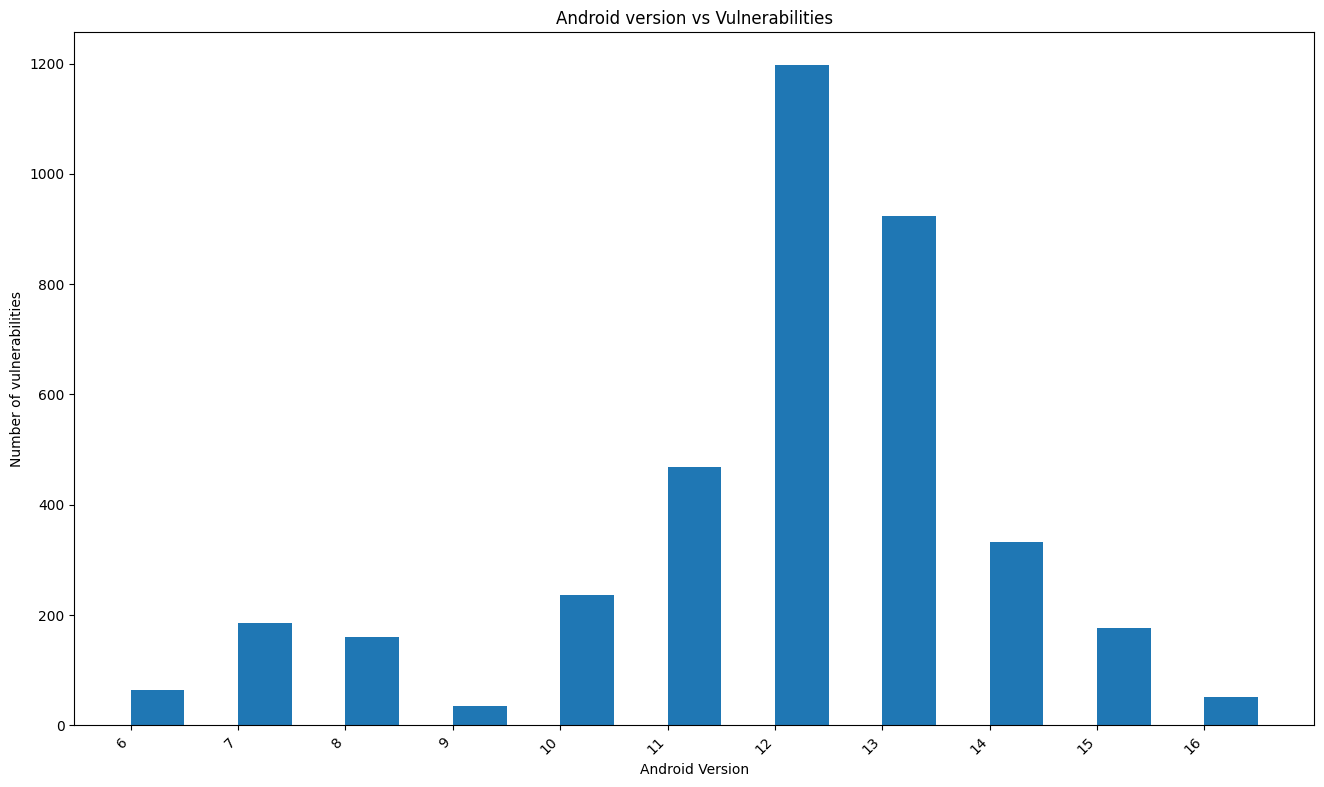

In [15]:
plt.figure(figsize=(16,9))
plt.bar(final_android_data.keys(), final_android_data.values(), align='edge', width=0.5)
plt.xticks(list(final_android_data.keys()))
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align to the right
plt.title("Android version vs Vulnerabilities")
plt.xlabel("Android Version")
plt.ylabel("Number of vulnerabilities")
plt.show()

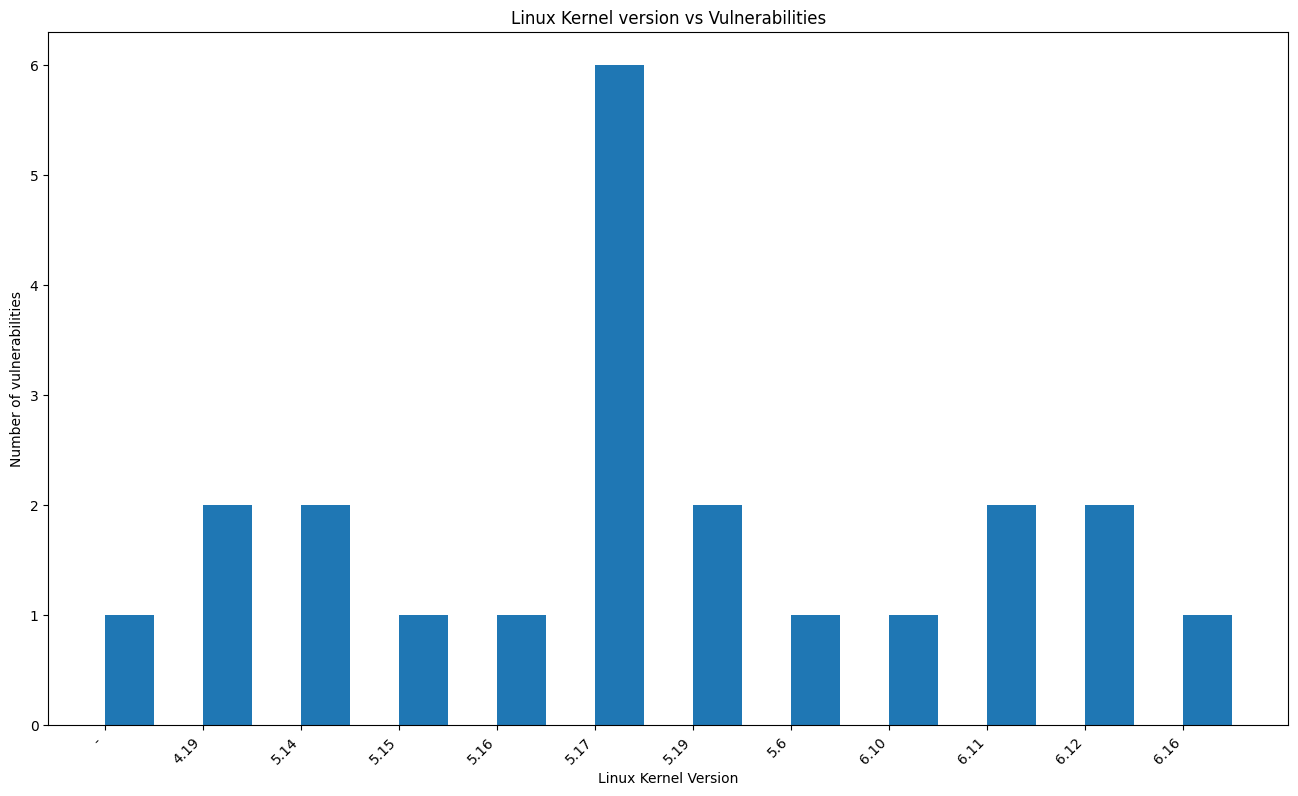

In [16]:
plt.figure(figsize=(16,9))
plt.bar(list(versions.keys())[:-1], list(versions.values())[:-1], align='edge', width=0.5)
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align to the right
plt.title("Linux Kernel version vs Vulnerabilities")
plt.xlabel("Linux Kernel Version")
plt.ylabel("Number of vulnerabilities")
plt.show()

In [17]:
all = pd.read_csv("cve_data.csv")

In [18]:
nvd = pd.read_csv("cve_count_analysis_2020_and_up.csv")

In [19]:
nvd

,CWE,num
0,Out-of-bounds Write,634
1,Out-of-bounds Read,634
2,Missing Authorization,257
3,Integer Overflow or Wraparound,148
4,Incorrect Default Permissions,138
...,...,...
120,Session Fixation,1
121,Incorrect Type Conversion or Cast,1
122,Improper Access Control,1
123,Missing Origin Validation in WebSockets,1


In [20]:
complete = pd.read_csv("cve_data_2020_and_up.csv")

In [21]:
complete

,cve_id,Name,description
0,CVE-2020-0009,Incorrect Default Permissions,"In calc_vm_may_flags of ashmem.c, there is a p..."
1,CVE-2020-0002,Use After Free,"In ih264d_init_decoder of ih264d_api.c, there ..."
2,CVE-2020-0003,Time-of-check Time-of-use (TOCTOU) Race Condition,"In onCreate of InstallStart.java, there is a p..."
3,CVE-2020-0004,Improper Handling of Exceptional Conditions,In generateCrop of WallpaperManagerService.jav...
4,CVE-2020-0006,Use of Uninitialized Resource,In rw_i93_send_cmd_write_single_block of rw_i9...
...,...,...,...
3502,CVE-2023-27392,Incorrect Default Permissions,Incorrect default permissions in the Intel(R) ...
3503,CVE-2023-45321,Cleartext Transmission of Sensitive Information,"The Android Client application, when enrolled ..."
3504,CVE-2023-42579,Cleartext Transmission of Sensitive Information,Improper usage of insecure protocol (i.e. HTTP...
3505,CVE-2023-46447,Cleartext Transmission of Sensitive Information,"The POPS! Rebel application 5.0 for Android, i..."


In [22]:
versions_android_cve_list = {}

for data in android.iterrows():
    prods = data[1]['affected_products']
    cve = data[1]['id']
    array = json.loads(prods.replace("'", '"'))
    for prod in array:
        if(prod['product']=='android'):
            try:
                version = float(prod['version'].split('.')[0])
                if version in versions_android_cve_list:
                    versions_android_cve_list[version].append(cve)
                else:
                    versions_android_cve_list[version] = [cve]
            except Exception as e:
                pass

In [23]:
import csv

for vers in versions_android_cve_list:
    data_list = pd.DataFrame(versions_android_cve_list[vers], columns=["CVE"])
    data_list.to_csv(f'android_{int(vers)}.csv', index=False)

In [24]:
crit = 481
high = 2759
med = 2036
low = 125

labels = ['CRITICAL', 'HIGH', "MEDIUM", "LOW"]
vals = [crit, high, med, low]

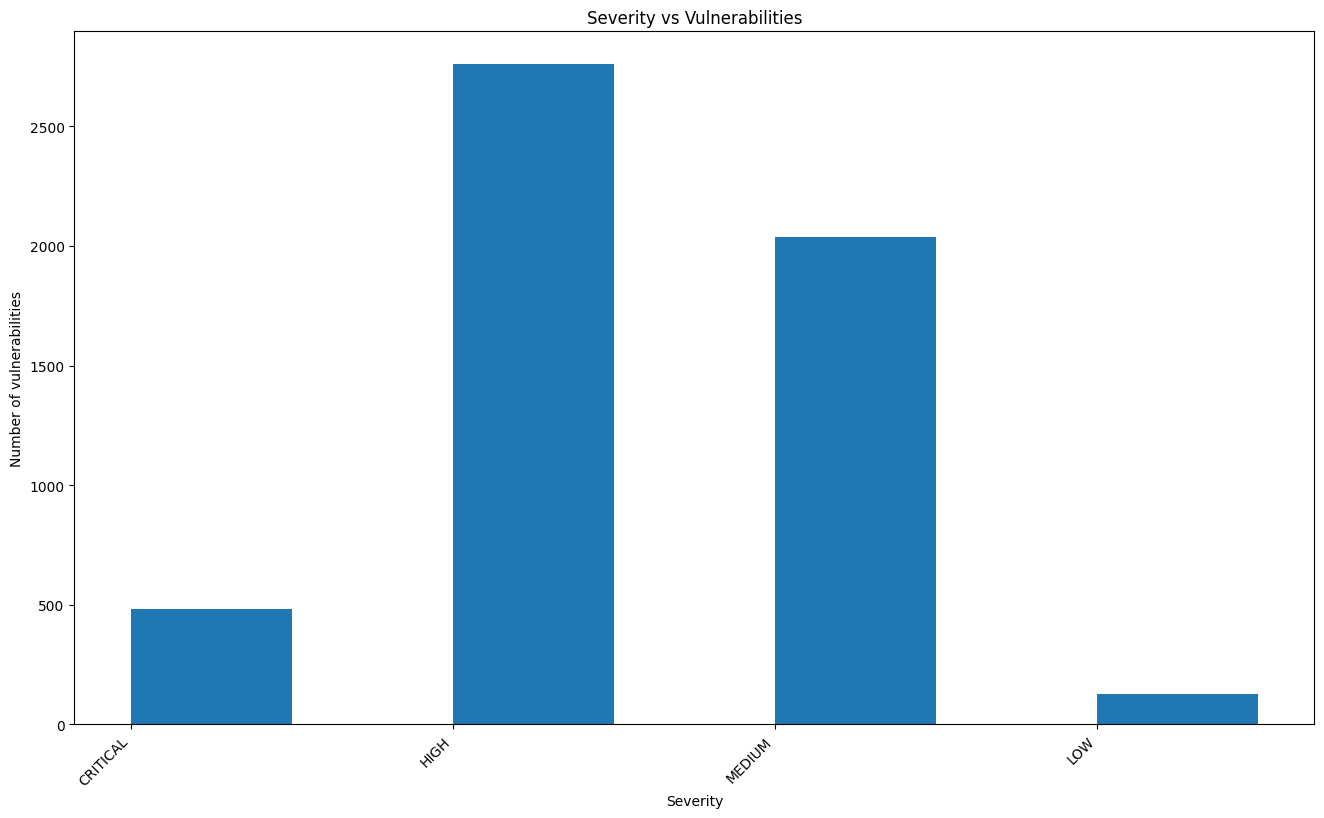

In [25]:
plt.figure(figsize=(16,9))
plt.bar(labels, vals, align='edge', width=0.5)
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align to the right
plt.title("Severity vs Vulnerabilities")
plt.xlabel("Severity")
plt.ylabel("Number of vulnerabilities")
plt.show()

In [29]:
vendors = set()
dataset = pd.read_csv('cve_data.csv')
for i in dataset['affected_products']:
    try:
        array = json.loads(i.replace("'", '"'))
        for data in array:
            vendors.add(data['vendor'])
    except Exception as e:
        pass

In [30]:
vendors

{'adobe',
 'alberta',
 'alfa',
 'apache',
 'apple',
 'arista',
 'arm',
 'arubanetworks',
 'bandisoft',
 'bentley',
 'blackberry',
 'bluetooth',
 'bluproducts',
 'bouncycastle',
 'broadcom',
 'brocade',
 'c-ares',
 'c-ares_project',
 'canonical',
 'cisco',
 'cypress',
 'debian',
 'dhcpcd_project',
 'e2fsprogs_project',
 'f5',
 'fedoraproject',
 'feep',
 'flac',
 'flac_project',
 'freebsd',
 'freetype',
 'giflib_project',
 'gnu',
 'google',
 'haxx',
 'health',
 'hp',
 'huawei',
 'ieee',
 'imagemagick',
 'imaginationtech',
 'intel',
 'ivanti',
 'kernel',
 'libexif_project',
 'libexpat_project',
 'libpng',
 'linux',
 'linuxfoundation',
 'lua',
 'mcafee',
 'mediatek',
 'microsoft',
 'mozilla',
 'nanopb_project',
 'netapp',
 'netbsd',
 'nodejs',
 'novell',
 'nvidia',
 'objective_systems',
 'opencv',
 'openssl',
 'opensuse',
 'opensuse_project',
 'openwrt',
 'oracle',
 'ovirt',
 'paloaltonetworks',
 'pepperl-fuchs',
 'phoenixcontact',
 'point-to-point_protocol_project',
 'pulsesecure',
 'pyth